In [ ]:
## Aula 3: Do catálogo ao espectro de potência angular
# Isabela, Louis, Bruno

In [191]:
# Importing python packages

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import glass.ext.camb
import glass.observations
import glass.shells
import glass.fields
import glass
from cosmology.compat.camb import Cosmology
import pymaster as nmt
import healpy as hp
import camb
import os
import warnings


rcParams['font.size'] = 14
rcParams['axes.labelsize'] = 14
rcParams['xtick.labelsize'] = 14
rcParams['ytick.labelsize'] = 14

## 1. Gerando um catálogo de galáxias

Vamos gerar um catálogo de galáxias utilizando o código GLASS. Ele assume que o campo de constraste de densidade segue uma distribuição lognormal. Podemos construir esse campo para que ele tenha o espectro de potência angular desejado.

### 1.a) Calculando o espectro de potência angular da matéria

In [192]:
# Onde salvar os arquivos de saída
storage = "../data/aula_3" # modificar para o caminho correto
matter_cls_dir = storage+'/matter_cls'
os.makedirs(os.path.dirname(f'{matter_cls_dir}/cls.npy'), exist_ok=True)
    
# Parâmetros da simulação
lmax = 300
zmin = 0.2
zmax = 1.2
dz = 0.2

# Parâmetros cosmológicos (Planck 2018)
H0 = 67.36
omch2 = 0.1225
ombh2 = 0.0223
As = 2.2e-9
ns = 0.96
tau = 0.06

pars = camb.set_params(H0=H0, omch2=omch2, ombh2=ombh2,
                        As=As, ns=ns, tau=tau,
                        NonLinear=camb.model.NonLinear_both)

# Cascas de redshift
zb = glass.shells.redshift_grid(zmin, zmax, dz=dz)

# Função janela (top-hat)
ws = glass.shells.tophat_windows(zb, dz=dz/100)

# Calculando o espectro de potência angular da matéria com CAMB
cls = glass.ext.camb.matter_cls(pars, lmax, ws)
np.save(f'{matter_cls_dir}/cls', cls) # matriz com Nmultipoles*Nzbins*(Nzbins+1)/2 elementos


/var/folders/80/8jdvtzhn1ll3hd209lpykmyc0000gp/T/ipykernel_28501/2027816051.py:28: UserWarning: first tophat window does not start at redshift zero
  ws = glass.shells.tophat_windows(zb, dz=dz/100)


In [193]:
# Calculando o espectro de potência do campo Gaussiano correspondente

# Resolução do mapa pixelizado
nside = 128
# Número de casacas de redshift cuja correlação será considerada (corr=None: todas as casacas são correlacionadas)
corr = None

# Número de bins de redshift e valor médio de cada bin
Nbins = len(zb)-1
zbar = (zb[1:]+zb[:-1])/2

# Load Cls da matéria
cls = np.load(matter_cls_dir+'/cls.npy')

# Definindo os campos lognormais
fields = glass.lognormal_fields(ws)

# Calculando os Cls Gaussianos    
Cls = glass.discretized_cls(cls, nside=nside, lmax=lmax, ncorr=corr)
gls = glass.solve_gaussian_spectra(fields, Cls)

# Salvando os Cls Gaussianos
os.makedirs(os.path.dirname(f'{matter_cls_dir}/gls.npy'), exist_ok=True)
arr = np.array(gls, dtype=object)
np.save(f'{matter_cls_dir}/gls', arr, allow_pickle=True)


### 1.b) Criando galáxias

In [194]:
# Onde queremos salvar nosso catálogo de galáxias
gdir = storage+'/galaxy_catalogs'

# Definindo a função de viés de galáxias e a densidade de galáxias por arcmin²

arcmin2_sky = 148510800

def bias_g(z):
  """Galaxy bias"""
  return 0.971 + 1.042*z # DESI Legacy blue galaxies

def dndz_g(z):
  """Galaxy redshift distribution (# of galaxies per arcmin² per redshift)"""
  return (6*1e7/arcmin2_sky) * glass.observations.smail_nz(z, 0.7, 0.8, 2.) # tuned for desi legacy
           

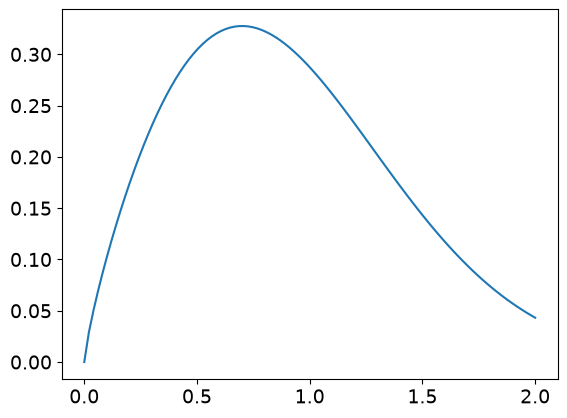

In [195]:
plt.plot(np.linspace(0, 2, 100), dndz_g(np.linspace(0, 2, 100)))

In [196]:
# Cosmologia
camb_back = camb.get_background(pars)
cosmo = Cosmology(camb_back)

# Load Gls
gls = np.load(f'{matter_cls_dir}/gls.npy', allow_pickle=True)


catalog_G = np.zeros(len(zb)-1, dtype=[('LON', object), ('LAT', object),
                                        ('Z_TRUE', object), ('KAPPA', object)])


# Gerando um campo de matéria lognormal a partir dos Gls
matter = glass.fields.generate_lognormal(gls, nside, ncorr=corr) 

# Calculando a convergência
convergence = glass.lensing.MultiPlaneConvergence(cosmo)

for i, delta_i in enumerate(matter): 

    if i > Nbins-1:
        continue

    zg_i, dndzg_i = glass.shells.restrict(zb, dndz_g(zb), ws[i])  # smail
    ngal = np.trapezoid(dndzg_i, zg_i)

    if ngal*arcmin2_sky < 1:
        warnings.warn(f"Nenhuma galáxia no bin {i}.", category=UserWarning, stacklevel=2)
        continue

    # Salvando a convergência em cada casca de redshift
    #convergence.dd_window(delta_i, ws[i])
    #kappa_i = convergence.kappa
    #catalog_G[i]['KAPPA'] = kappa_i

    # Gerando as posições das galáxias a partir do campo de densidade (ngal + contraste delta, com viés) na casca i
    pos_gal = glass.points.positions_from_delta(ngal, delta_i,bias=glass.points.effective_bias(zb, bias_g(zb), ws[i]), remove_monopole=True)
    # Remover o monopolo assegura que dndz será o que inserimos mas muda o viés efetivo

    # Salvando o catálogo --------------
    result_list = []

    for lon, lat, count in pos_gal:
        # lon e lat são arrays com as posições de cada galáxia que foi amostrada 
        # count é o número total de galáxias amostradas na casca
        result_list.append((lon, lat, count))

    if result_list:
        gal_lons, gal_lats, gal_counts = zip(*result_list)
        gal_lons = np.concatenate(gal_lons)
        gal_lats = np.concatenate(gal_lats)
    
        gal_counts = np.sum(gal_counts)
        gal_z = glass.galaxies.redshifts_from_nz(gal_counts, ws[i].za, ws[i].wa)

    else:
        gal_lons, gal_lats, gal_z = [], [], []
    
    catalog_G[i]['LON'] = gal_lons # deg
    catalog_G[i]['LAT'] = gal_lats # deg
    catalog_G[i]['Z_TRUE'] = gal_z

os.makedirs(os.path.dirname(f'{gdir}/catalog_G.npy'), exist_ok=True)
np.save(f'{gdir}/catalog_G', catalog_G)

/var/folders/80/8jdvtzhn1ll3hd209lpykmyc0000gp/T/ipykernel_28501/2716161952.py:14: DeprecationWarning: use glass.generate() instead
  matter = glass.fields.generate_lognormal(gls, nside, ncorr=corr)
/var/folders/80/8jdvtzhn1ll3hd209lpykmyc0000gp/T/ipykernel_28501/2716161952.py:54: UserWarning: when sampling galaxies, redshifts_from_nz() is often not the function you want. Try redshifts() instead. Use warn=False to suppress this warning.
  gal_z = glass.galaxies.redshifts_from_nz(gal_counts, ws[i].za, ws[i].wa)


## 2. Obtendo um mapa pixelizado

In [197]:

gal_count_map = np.zeros(shape=(Nbins, hp.nside2npix(nside)))

for i in range(Nbins):

    gal_pix_index  = hp.ang2pix(nside, catalog_G[i]['LON'], catalog_G[i]['LAT'], lonlat=True)
    unique, counts = np.unique(gal_pix_index, return_counts=True)
    gal_count_map[i,unique] = counts # galaxy counts N in each redshift bin i    

os.makedirs(os.path.dirname(f'{gdir}/gal_count_map.npy'), exist_ok=True)

if f'gal_count_map.npy' in os.listdir(gdir):
    warnings.warn(f'Overwritting.', category=UserWarning, stacklevel=2)

np.save(f'{gdir}/gal_count_map.npy', gal_count_map)


/opt/anaconda3/envs/iaschool/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3775: UserWarning: Overwritting.
  exec(code_obj, self.user_global_ns, self.user_ns)


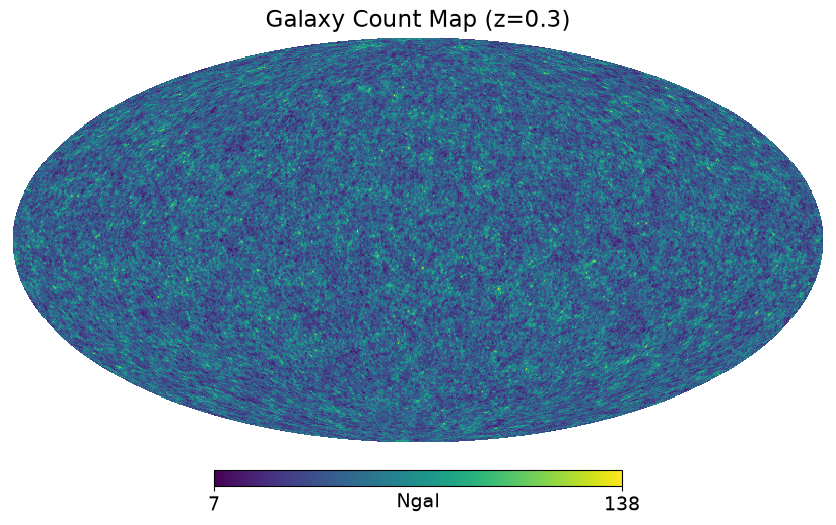

In [139]:
# Visualizando o mapa

hp.mollview(gal_count_map[0], title='Galaxy Count Map (z=0.3)', unit='Ngal', cmap='viridis')

## 4. Adicionando photo-z

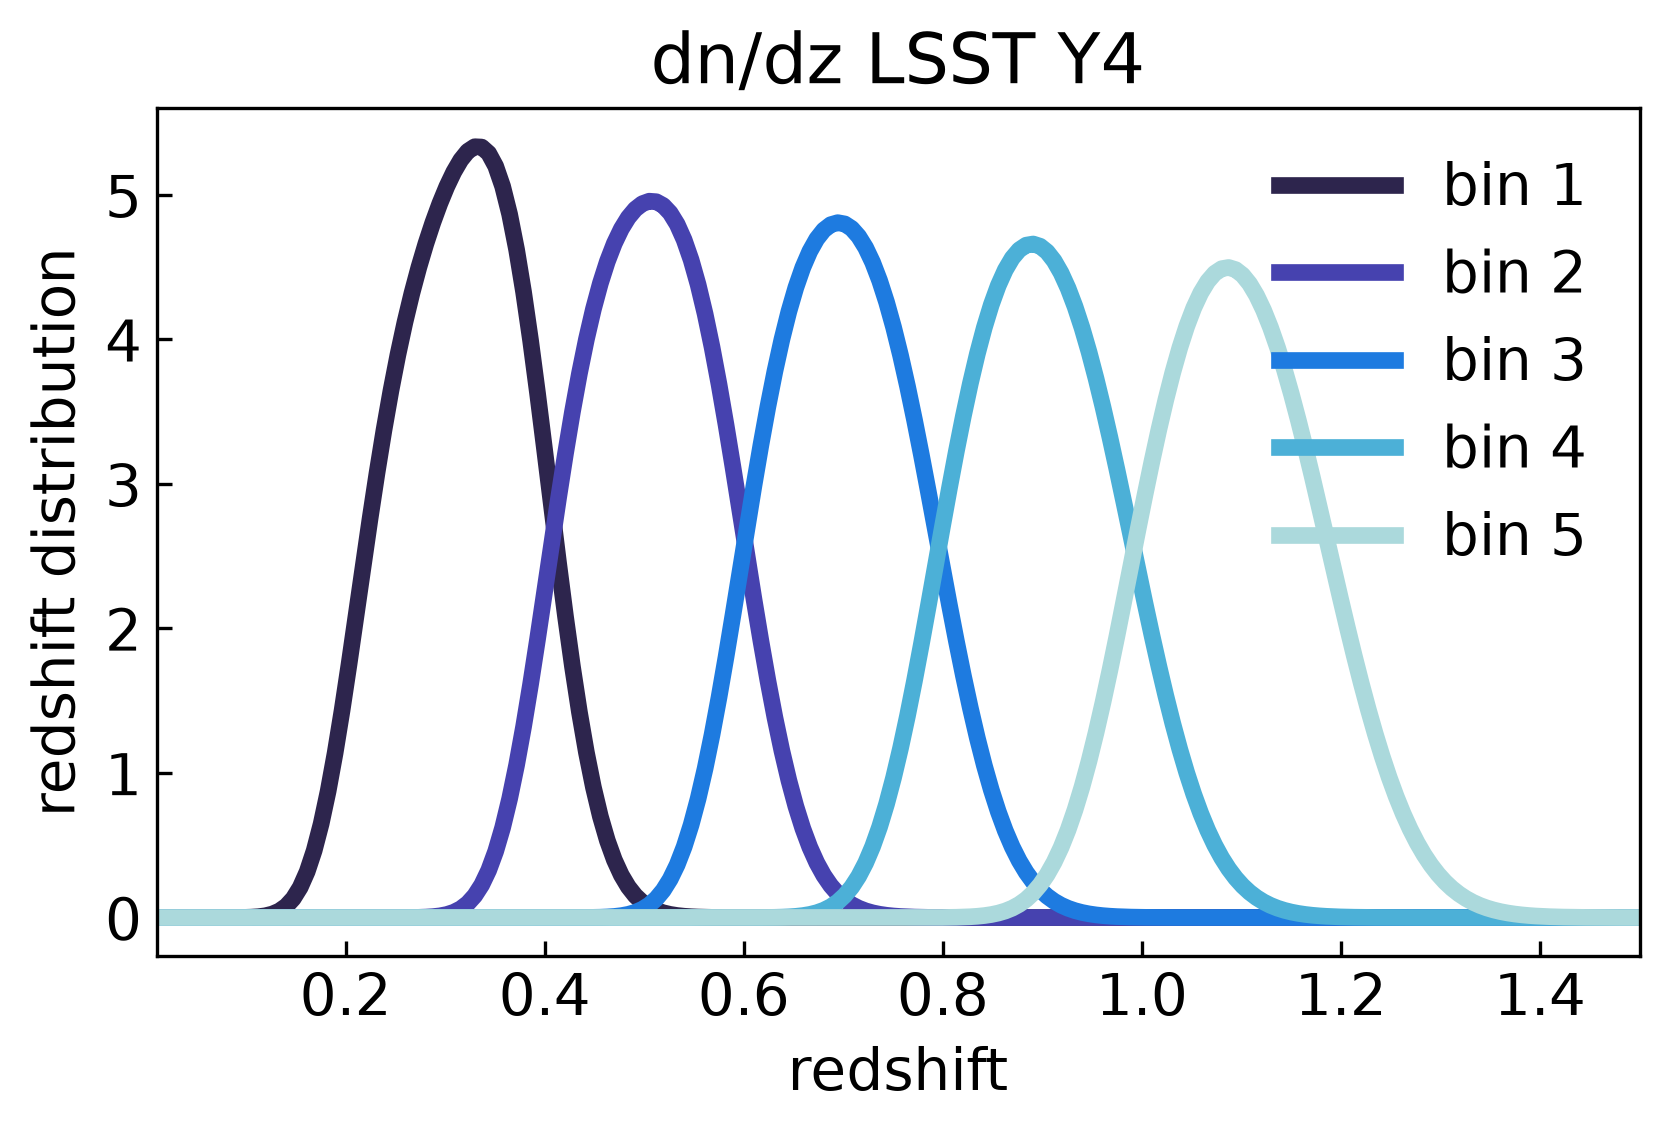

In [200]:
# Vamos inserir photo-zs esperados para o LSST Y4 (adaptado de https://github.com/LSSTDESC/CCLX/blob/master/LSST_SRD_Redshift_Distributions_and_Binning.ipynb)

# Importando modulos do LSST
from lsst_galaxy_sample import LSSTGalaxySample as lsst
import cmasher as cmr

# Defina o intervalo de redshift e os anos de previsão do LSST
redshift_range = np.linspace(0.0, 3.5, 500)
forecast_years = ["1", "4", "7", "10"]  # LSST forecasting epochs
samples = {}

# Armazene os dados em um dicionário "samples"
for year in forecast_years:
    init = lsst(year, redshift_range)
    samples[year] = {
        "source_nz": init.source_sample(normalized=True, save_file=True),
        "lens_nz": init.lens_sample(normalized=True, save_file=True),
        "source_bins": init.source_bins(normalized=True, save_file=True),
        "lens_bins": init.lens_bins(normalized=True, save_file=True),
        "source_bin_centers": init.source_bin_centers(decimal_places=3),
        "lens_bin_centers": init.lens_bin_centers(decimal_places=3)
    }

# Defina cores bonitas para a figura
colors = {
    "lenses": {
        "1": cmr.take_cmap_colors('cmr.freeze', len(samples["1"]["lens_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
        "10": cmr.take_cmap_colors('cmr.freeze', len(samples["10"]["lens_bins"]),
                                   cmap_range=(0.2, 0.85), return_fmt='hex'),
        "4": cmr.take_cmap_colors('cmr.freeze', len(samples["4"]["lens_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
        "7": cmr.take_cmap_colors('cmr.freeze', len(samples["7"]["lens_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
    },
    "sources": {
        "1": cmr.take_cmap_colors('cmr.ember', len(samples["1"]["source_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
        "10": cmr.take_cmap_colors('cmr.ember', len(samples["10"]["source_bins"]),
                                   cmap_range=(0.2, 0.85), return_fmt='hex'),
        "4": cmr.take_cmap_colors('cmr.ember', len(samples["4"]["source_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
        "7": cmr.take_cmap_colors('cmr.ember', len(samples["7"]["source_bins"]),
                                  cmap_range=(0.2, 0.85), return_fmt='hex'),
    }
}


year = "4"
bin_type = "lens_bins"
sample_type = "lenses"

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
lw=4

for bin_idx, (key, data) in enumerate(samples[year][bin_type].items()):
    ax.plot(redshift_range,
            data,
            label=f"bin {key+1}",
            color=colors[sample_type][year][bin_idx],
            linestyle='-',
            lw=lw)

ax.set_xlim(0.01, 1.5)
ax.set_xlabel("redshift")
ax.set_ylabel("redshift distribution")
ax.set_title(f"dn/dz LSST Y{year}")
ax.tick_params(direction='in')
ax.legend(frameon=False, ncol=1)
ax.tick_params(axis='both', which='major')

plt.tight_layout()
plt.show()

In [141]:
# Use the LSST dn/dz distributions loaded and plotted above (samples[year][bin_type])
z_arr = redshift_range
dndz_2d = np.array(list(samples[year][bin_type].values()))  # shape (Nbins_LSST, len_z)

# Build M[j, i] = integral_{zb[i]}^{zb[i+1]} dndz_2d[j](z) dz via CDF differences
dz = np.diff(z_arr)
M = np.zeros((Nbins, Nbins))
for j in range(Nbins):
    mid = 0.5 * (dndz_2d[j, :-1] + dndz_2d[j, 1:])
    cdf = np.concatenate([[0.0], np.cumsum(mid * dz)])
    cdf_at_edges = np.interp(zb, z_arr, cdf)
    M[j, :] = np.diff(cdf_at_edges)

# Column-normalise: scatter[j, i] = p(z_obs=j | z_true=i)
col_sums = M.sum(axis=0)
scatter = np.where(col_sums[np.newaxis, :] > 0, M / col_sums[np.newaxis, :], 0.0)

g_map = np.load(f'{gdir}/gal_count_map.npy', allow_pickle=True)
g_map_obs = np.zeros(np.shape(g_map), dtype=float)

for i in range(Nbins):

    # Pixel index for every galaxy in true bin i
    pix_list = np.repeat(np.arange(hp.nside2npix(nside)), g_map[i].astype(int))

    # Sample observed bin for each galaxy using the scatter column
    obs_bins = np.random.choice(Nbins, size=len(pix_list), p=scatter[:, i])

    # Accumulate counts into the observed map (pixel positions unchanged)
    np.add.at(g_map_obs, (obs_bins, pix_list), 1)

os.makedirs(os.path.dirname(f'{gdir}_obs/gal_count_map.npy'), exist_ok=True)
np.save(f'{gdir}_obs/gal_count_map.npy', g_map_obs)

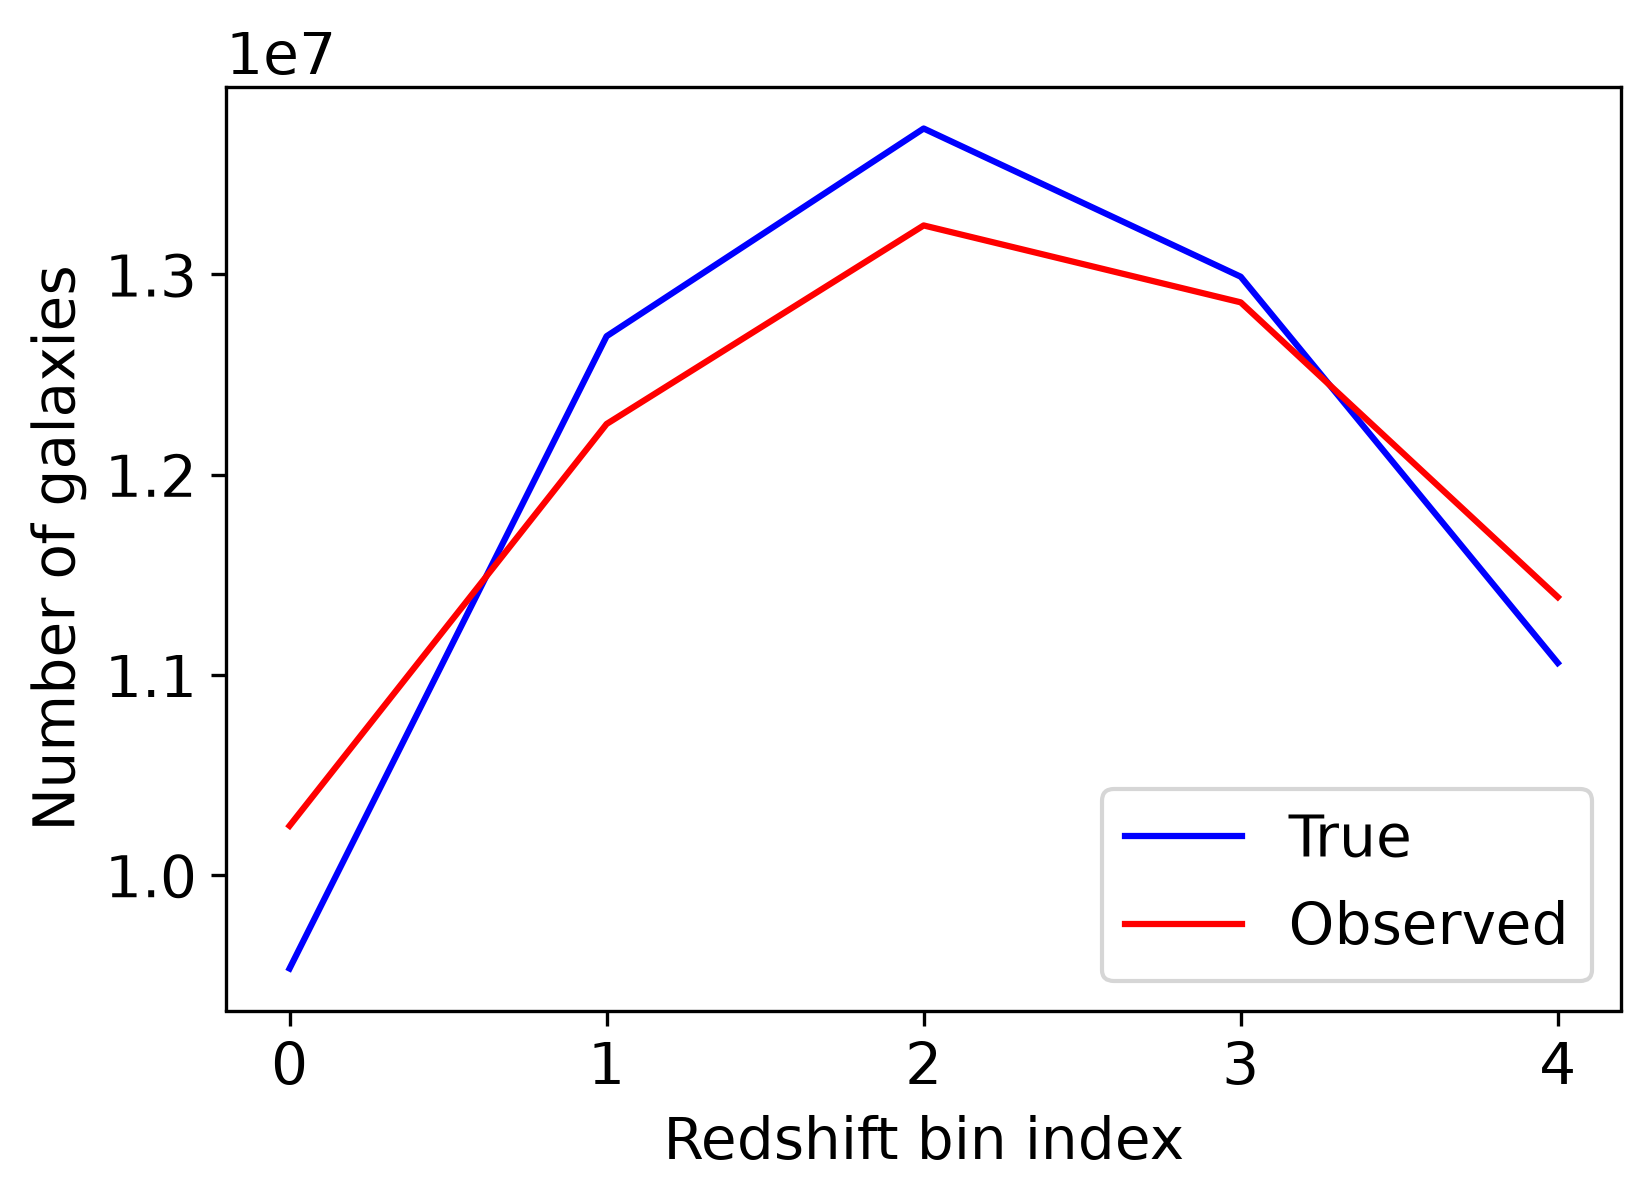

In [201]:
# Plotando as distribuicoes de redshift dos mapas

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
ax.plot(np.sum(gal_count_map, axis=1), label='True', color='blue')
ax.plot(np.sum(g_map_obs, axis=1), label='Observed', color='red')
ax.set_xlabel('Redshift bin index')
ax.set_ylabel('Number of galaxies')
plt.legend()

Fazer gráfico em theta, z, comparando o mapa sem photo-z com o mapa com photo-z

## 5. Adicionando uma máscara

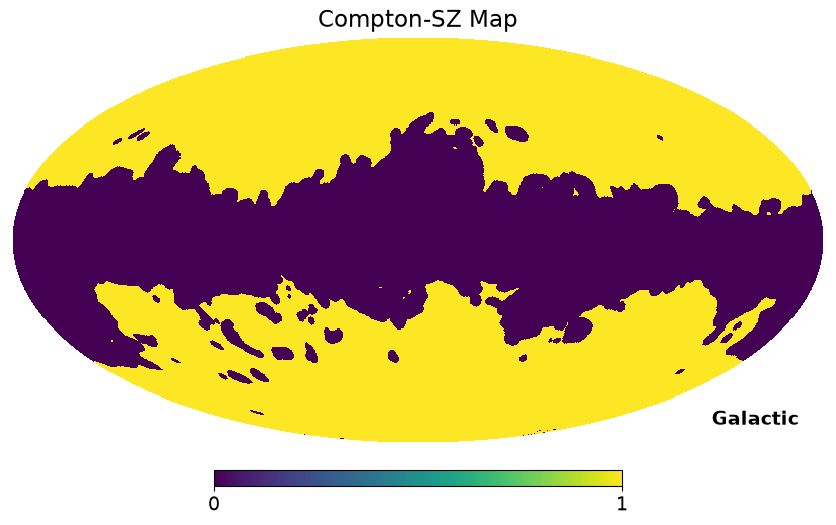

In [203]:
# Vamos usar a máscara de SZ do Planck

# Ler o mapa HEALPix diretamente
#mask_planck = hp.read_map(f'{storage}/COM_Mask_Compton-SZMap_2048_R2.00.fits', field=0)
#mask_planck_new = hp.ud_grade(mask_planck, nside_out=256)
#np.save(f'{storage}/mask_planck_SZ_map.npy', mask_planck_new)
mask_planck = np.load(f'./mask_planck_SZ_map.npy', allow_pickle=True)

# Visualizar o mapa na projeção Mollweide em coordenadas galáticas
hp.mollview(mask_planck, title="Compton-SZ Map", coord=["G"])
    

Exercício: encontrar o nside da máscara.

In [205]:
hp.npix2nside(len(mask_planck))

256

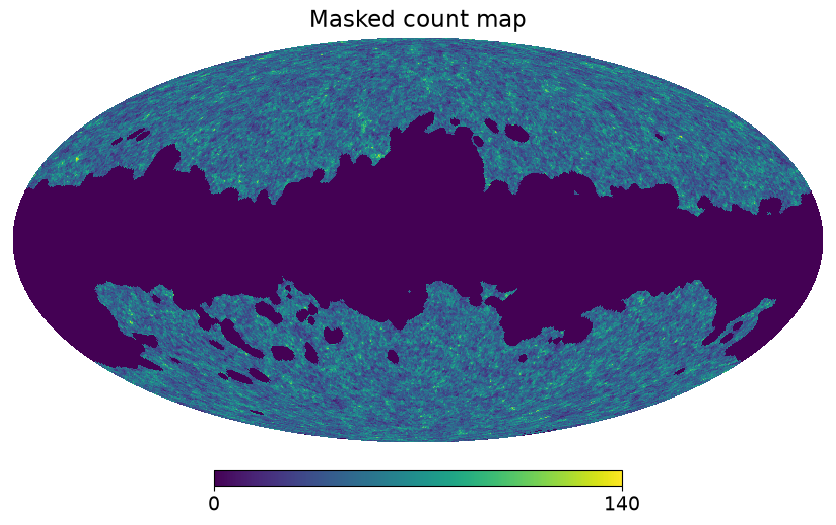

In [206]:
# Diminua a resolução da máscara para ser a mesma do mapa de galáxias (nside=128)
mask_planck = hp.ud_grade(mask_planck, nside_out=nside)

hp.mollview(gal_count_map[0] * mask_planck, title="Masked count map")

## 3. Calculando o espectro de potência angular

### 3.a) Sem máscara, com healpy

In [207]:
# Onde queremos salvar os Cls
cls_dir = storage+'/cls_no_mask'
gal_count_map = np.load(f'{gdir}/gal_count_map.npy')

# Calculando Cls em bins tomográficos
n_ells = lmax + 1
cls_gg_no_mask = np.zeros(shape=(n_ells, Nbins, Nbins), dtype='float32')
gal_delta_map = np.zeros(shape=(Nbins, hp.nside2npix(nside)))
alm_g = np.zeros(shape=(Nbins, np.sum(np.arange(lmax+1)+1)), dtype='complex')

for i in range(Nbins):
    ng_mean = np.mean(gal_count_map[i])
    gal_delta_map[i] = (gal_count_map[i] - ng_mean)/ng_mean
    alm_g[i] = hp.map2alm(gal_delta_map[i],lmax=lmax)

cls_gg_pseudo = hp.alm2cl(alm_g, lmax=lmax)

# Reorganizando a matriz       
idx = 0
for n in range(Nbins):
    for i in range(Nbins - n):
        j = n + i
        cls_gg_no_mask[:,i,j] = cls_gg_no_mask[:,j,i] = cls_gg_pseudo[idx][np.newaxis,:]
        idx += 1

# Salvando        
os.makedirs(os.path.dirname(f'{cls_dir}/Cls_gg_no_mask.npy'), exist_ok=True)
np.save(f'{cls_dir}/Cls_gg_no_mask', cls_gg_no_mask)

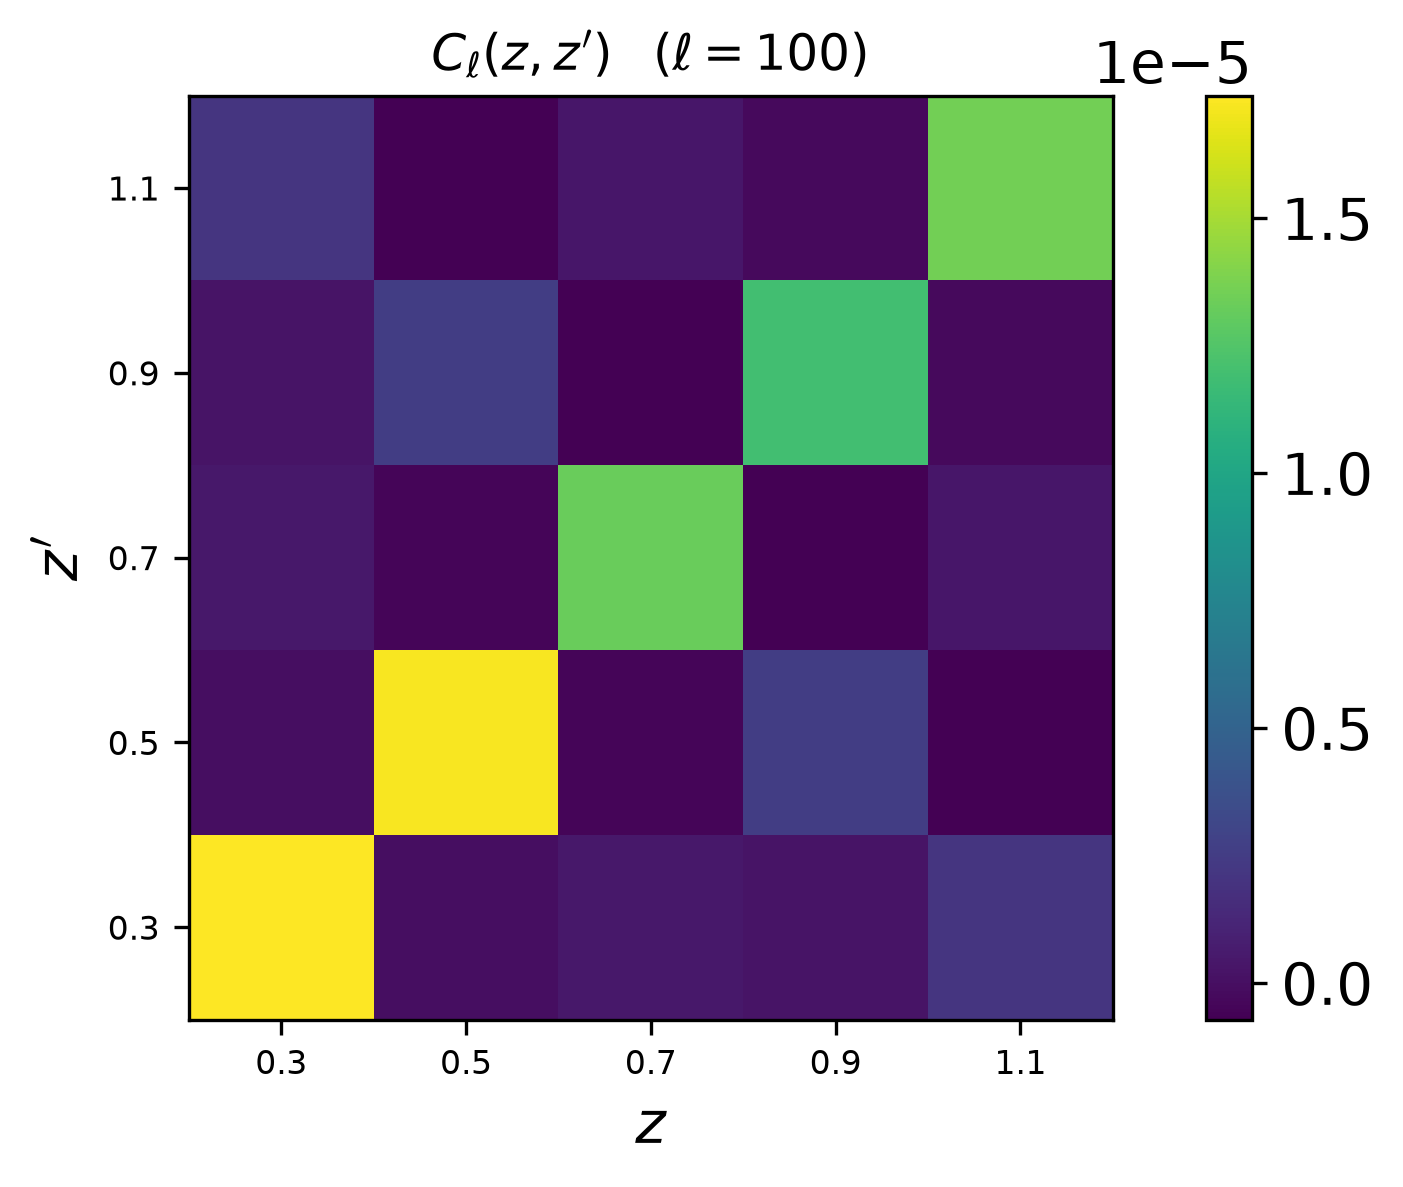

In [208]:
# Plot em bins de z, z'

fig, ax = plt.subplots(dpi=300)
fig.set_figwidth(8)
fig.set_figheight(4)
img=ax.imshow(cls_gg_no_mask[100,:,:].T, origin='lower')#,extent=[0,100,0,100])
plt.title(r"${C_\ell}(z,z') \;\;\; (\ell=100)$", fontsize=12)
ax.set_xlabel('$z$')
ax.set_ylabel("$z'$")
ax.set_xticks(np.arange(5))
ax.set_xticklabels(np.round(zbar, 1).tolist(), fontsize=8)
ax.set_yticks(np.arange(5))
ax.set_yticklabels(np.round(zbar, 1).tolist(), fontsize=8)
fig.colorbar(img,ax=ax)


### 3.b) Com máscara e invertendo os pseudo-Cls

In [209]:
# Onde queremos salvar os Cls
cls_dir = storage+'/cls'
gal_count_map = np.load(f'{gdir}/gal_count_map.npy')

# Bandpowers
bs = 5
b = nmt.NmtBin.from_lmax_linear(lmax, bs) # binning in bandpowers, starts from ell=2 and removes last bandpowers if bin is incomplete
n_bands = b.get_n_bands()

# Calculando a matriz de acoplamento
gmask = nmt.NmtField(mask_planck, None, spin=0, lmax=lmax, masked_on_input=False)
w_gg = nmt.NmtWorkspace()
w_gg.compute_coupling_matrix(gmask, gmask, b)

# Calculando pseudo-cls em bins tomográficos

cls_gg = np.zeros(shape=(n_bands, Nbins, Nbins), dtype='float32')
cls_gg_pseudo_reshape = np.zeros(shape=(lmax+1, Nbins, Nbins), dtype='float32')

gal_delta_map = np.zeros(shape=(Nbins, hp.nside2npix(nside)))
alm_g = np.zeros(shape=(Nbins, np.sum(np.arange(lmax+1)+1)), dtype='complex')

for i in range(Nbins):
    map_masked = gal_count_map[i] * mask_planck
    ng_mean = np.mean(map_masked[mask_planck==1])
    gal_delta_map[i] = ((map_masked - ng_mean)/ng_mean) * mask_planck  # zera fora da mascara (transforma mask*delta)
    alm_g[i] = hp.map2alm(gal_delta_map[i],lmax=lmax)

cls_gg_pseudo = hp.alm2cl(alm_g, lmax=lmax)

# Invertendo os pseudo-cls
        
idx = 0
for n in range(Nbins):
    for i in range(Nbins - n):
        j = n + i
        cls_gg_pseudo_reshape[:,i,j] = cls_gg_pseudo_reshape[:,j,i] = cls_gg_pseudo[idx][np.newaxis,:]
        cls_gg[:,i,j] = cls_gg[:,j,i] = w_gg.decouple_cell(cls_gg_pseudo[idx][np.newaxis,:], cl_bias=None)
        idx += 1

# Salvando        
os.makedirs(os.path.dirname(f'{cls_dir}/Cls_gg.npy'), exist_ok=True)
np.save(f'{cls_dir}/Cls_gg', cls_gg)
    

f_{sky} = 0.566


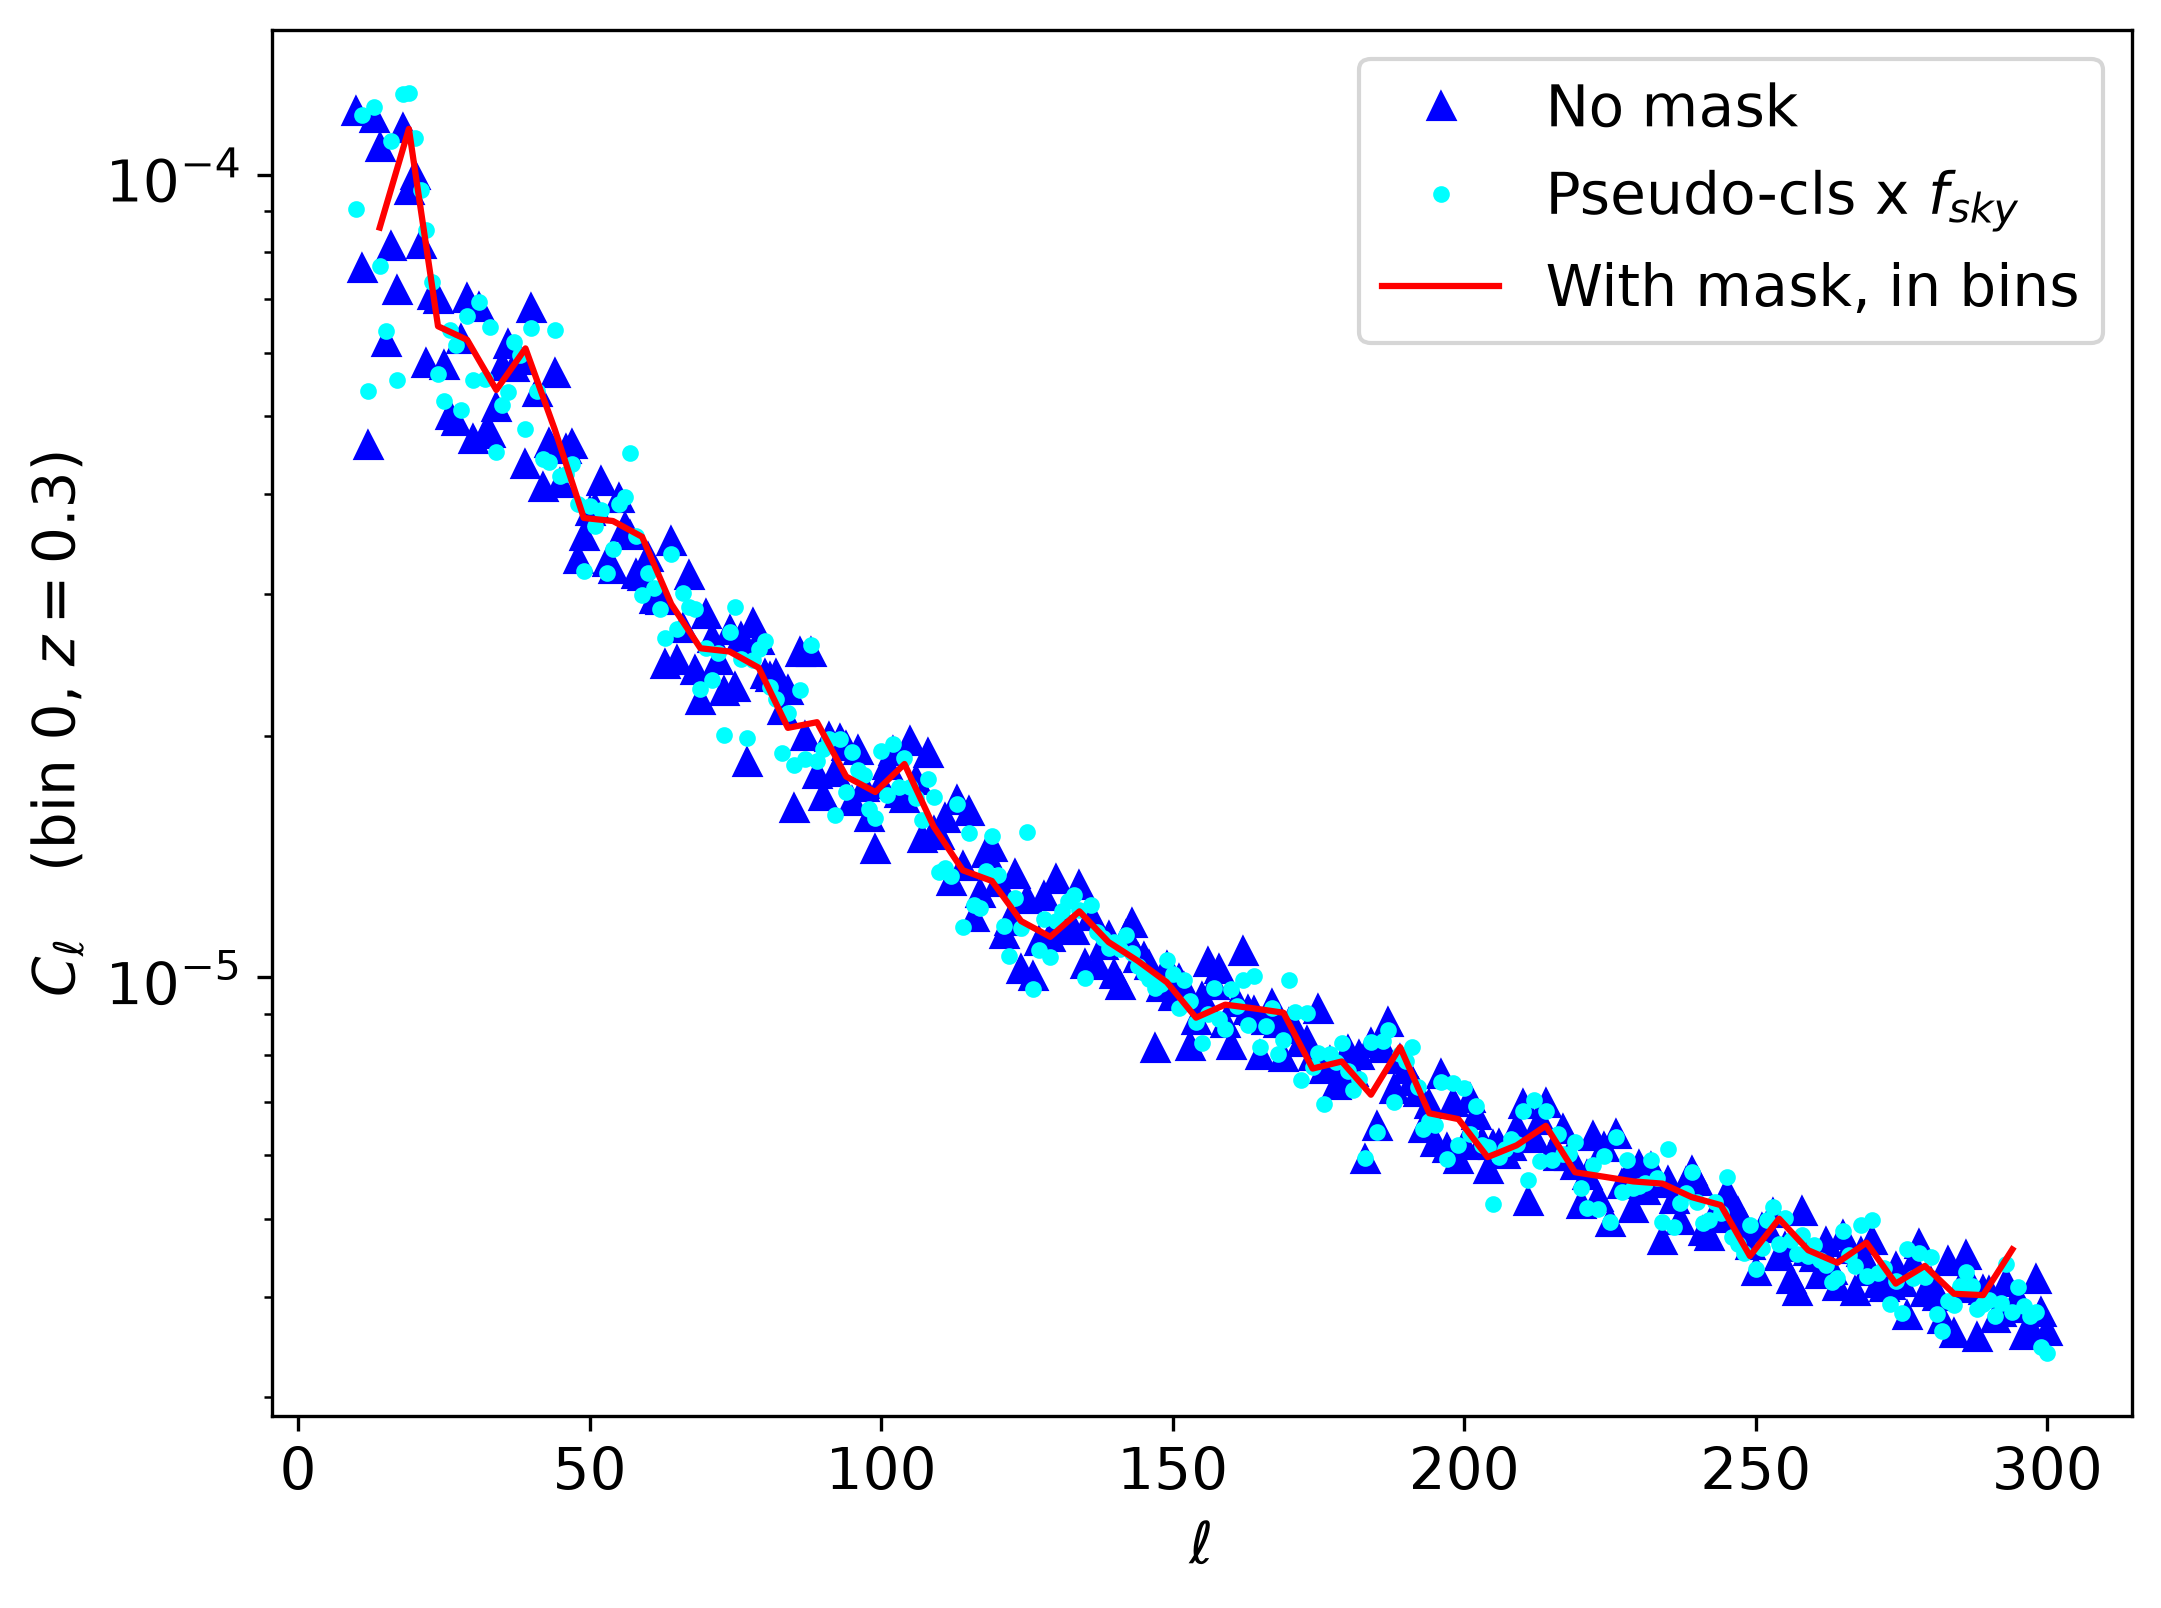

In [210]:
# Estimar fsky para máscara binária
fsky = np.sum(mask_planck)/len(mask_planck)
print(f'f_{{sky}} = {fsky:.3f}')

# Plotando os Cls
lmin = 10

fig, ax = plt.subplots(figsize=(8,6), dpi=300)
ax.plot(np.arange(lmin, lmax+1), cls_gg_no_mask[lmin:,0,0], '^', label='No mask', color='blue')
ax.plot(np.arange(lmin, lmax+1), (1/fsky)*cls_gg_pseudo_reshape[lmin:,0,0], '.', label='Pseudo-cls x $f_{sky}$', color='cyan')
ax.plot(b.get_effective_ells()[int(lmin/bs):], cls_gg[:,0,0][int(lmin/bs):], label='With mask, in bins', color='r')
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell \;\;\;$ (bin 0, $z=0.3$)')
plt.yscale('log')
ax.legend()
plt.show()

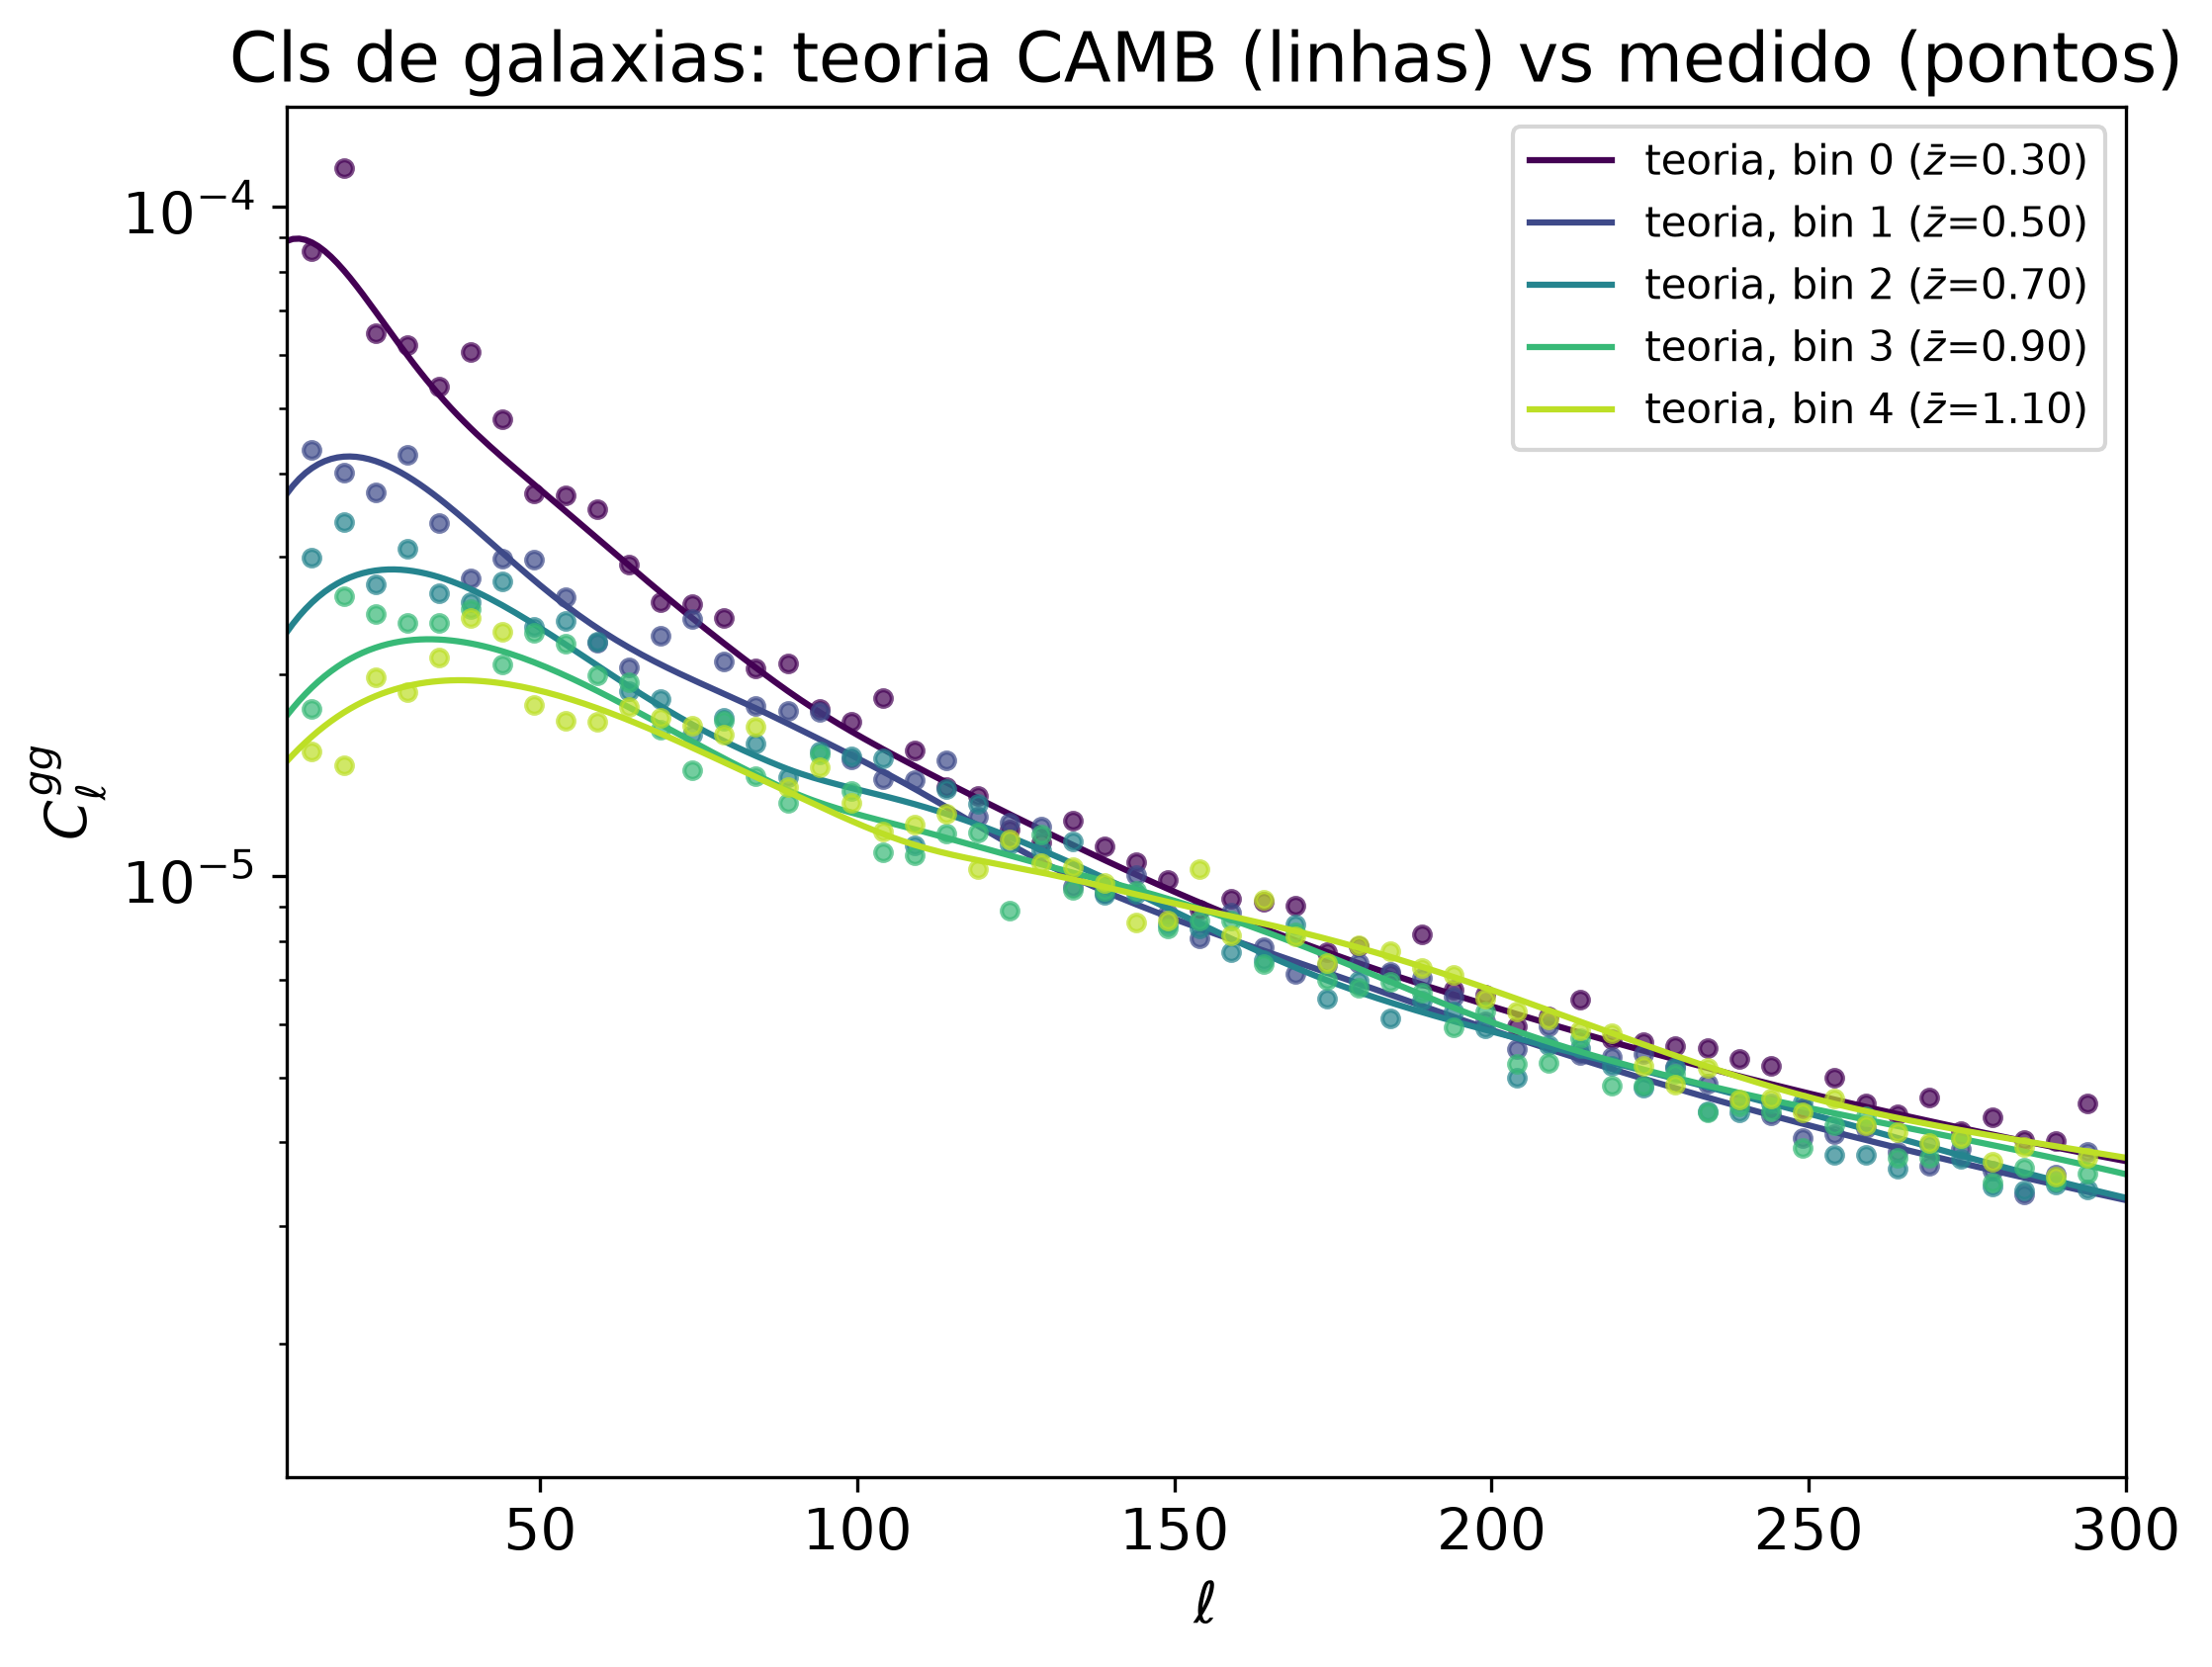

In [211]:
from camb.sources import SplinedSourceWindow


# Definindo uma janela por bin: janela = ws[i], vies = bias_g(z)
pars.SourceWindows = [
    SplinedSourceWindow(z=np.asarray(ws[i].za), W=np.asarray(ws[i].wa),
                        source_type='counts', bias_z=bias_g(np.asarray(ws[i].za)))
    for i in range(Nbins)
]

# Apenas clustering (densidade); desliga RSD, lenteamento, etc. -> como na sim.
st = pars.SourceTerms
st.counts_density = True
st.counts_redshift = st.counts_lensing = st.counts_velocity = False
st.counts_radial = st.counts_timedelay = False
st.counts_ISW = st.counts_potential = st.counts_evolve = False

pars.set_for_lmax(lmax)
results_gg = camb.get_results(pars)
cls_dict = results_gg.get_source_cls_dict(raw_cl=True)   # C_ell (sem l(l+1)/2pi)

# Matriz tomografica C_ell^{gg}[ell, i, j] (chaves 'WixWj', 1-indexadas)
ncl = len(cls_dict['W1xW1'])
ells_th = np.arange(ncl)
cls_gg_theory = np.zeros((ncl, Nbins, Nbins))

for i in range(Nbins):
    for j in range(Nbins):
        key = f'W{i+1}xW{j+1}' if f'W{i+1}xW{j+1}' in cls_dict else f'W{j+1}xW{i+1}'
        cls_gg_theory[:, i, j] = cls_dict[key]

# Plot: auto-Cls por bin (+ medidos)
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
colors = plt.cm.viridis(np.linspace(0, 0.9, Nbins))

for i in range(Nbins):

    ax.plot(ells_th[lmin:], cls_gg_theory[lmin:, i, i], color=colors[i],
            label=fr'teoria, bin {i} ($\bar z$={zbar[i]:.2f})')
    
    ax.plot(b.get_effective_ells()[int(lmin/bs):], cls_gg[:, i, i][int(lmin/bs):], 'o', ms=4,
                color=colors[i], alpha=0.7)
ax.set_xlim(lmin, lmax)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^{gg}$')
plt.yscale('log')
ax.set_title('Cls de galaxias: teoria CAMB (linhas)'
             + (' vs medido (pontos)' ))
ax.legend(fontsize=10)
plt.show()

Como quantificar o ajuste dos dados à teoria?

## Covariância

In [212]:
# Covariância dos Cls de galáxias (auto-espectros por bin), binados em multipolos
# ------------------------------------------------------------------------------
# Covariância Gaussiana (Knox) do vetor de dados { C_b^{ii} } -- o auto-Cl de cada
# bin de redshift i, binado nos MESMOS bandpowers do pymaster (`b`). Diagonal em
# bandpower:
#     Cov(C_b^{ii}, C_b^{jj}) = 2 / nu_b * ( Ctot_b^{ij} )^2
# com  Ctot = C_gg (sinal) + ruido de shot (diagonal em i)  e
#      nu_b = fsky * sum_{l no bandpower b} (2l+1)   (mesmos bins do pymaster).

Ng = Nbins                          # numero de bins de galaxias
n_bands = b.get_n_bands()
ell_eff = b.get_effective_ells()

# --- sinal teorico binado com os bandpowers do pymaster (mesma binagem da medida)
cl_full = cls_gg_theory[:lmax + 1]                      # (lmax+1, Ng, Ng)
cl_gg_b = b.bin_cell(
    cl_full.reshape(lmax + 1, Ng * Ng).T               # (Ng*Ng, lmax+1)
).reshape(Ng, Ng, n_bands)                             # (Ng, Ng, n_bands)

# --- ruido de shot por bin: N_i = 1/nbar_i  (nbar = galaxias por esferorradiano)
nbar_g_bin = np.array([gal_count_map[i].sum() / (4 * np.pi) for i in range(Ng)])
N_gg = 1.0 / nbar_g_bin                                # (Ng,)

# --- espectro total = sinal + ruido (ruido so na diagonal i=j) ---
Cgg_tot_b = cl_gg_b.copy()
for i in range(Ng):
    Cgg_tot_b[i, i, :] += N_gg[i]

# --- contagem de modos por bandpower, com fsky e os MESMOS bins do pymaster ---
nu_b = np.array([fsky * np.sum(2 * b.get_ell_list(bb) + 1) for bb in range(n_bands)])

# --- covariancia dos auto-Cls: cov_auto[b, i, j] = Cov(C_b^{ii}, C_b^{jj}) ---
cov_auto = np.zeros((n_bands, Ng, Ng))
for bb in range(n_bands):
    cov_auto[bb] = (2.0 / nu_b[bb]) * Cgg_tot_b[:, :, bb] ** 2

# incerteza (1 sigma) do auto-Cl de cada bin = raiz da variancia (diagonal i=j)
sigma_auto = np.stack([np.sqrt(np.diag(cov_auto[bb])) for bb in range(n_bands)])  # (n_bands, Ng)

print("cov_auto shape:", cov_auto.shape, " (n_bands, Nbins, Nbins)")
print("sigma_auto shape:", sigma_auto.shape)

cov_auto shape: (59, 5, 5)  (n_bands, Nbins, Nbins)
sigma_auto shape: (59, 5)


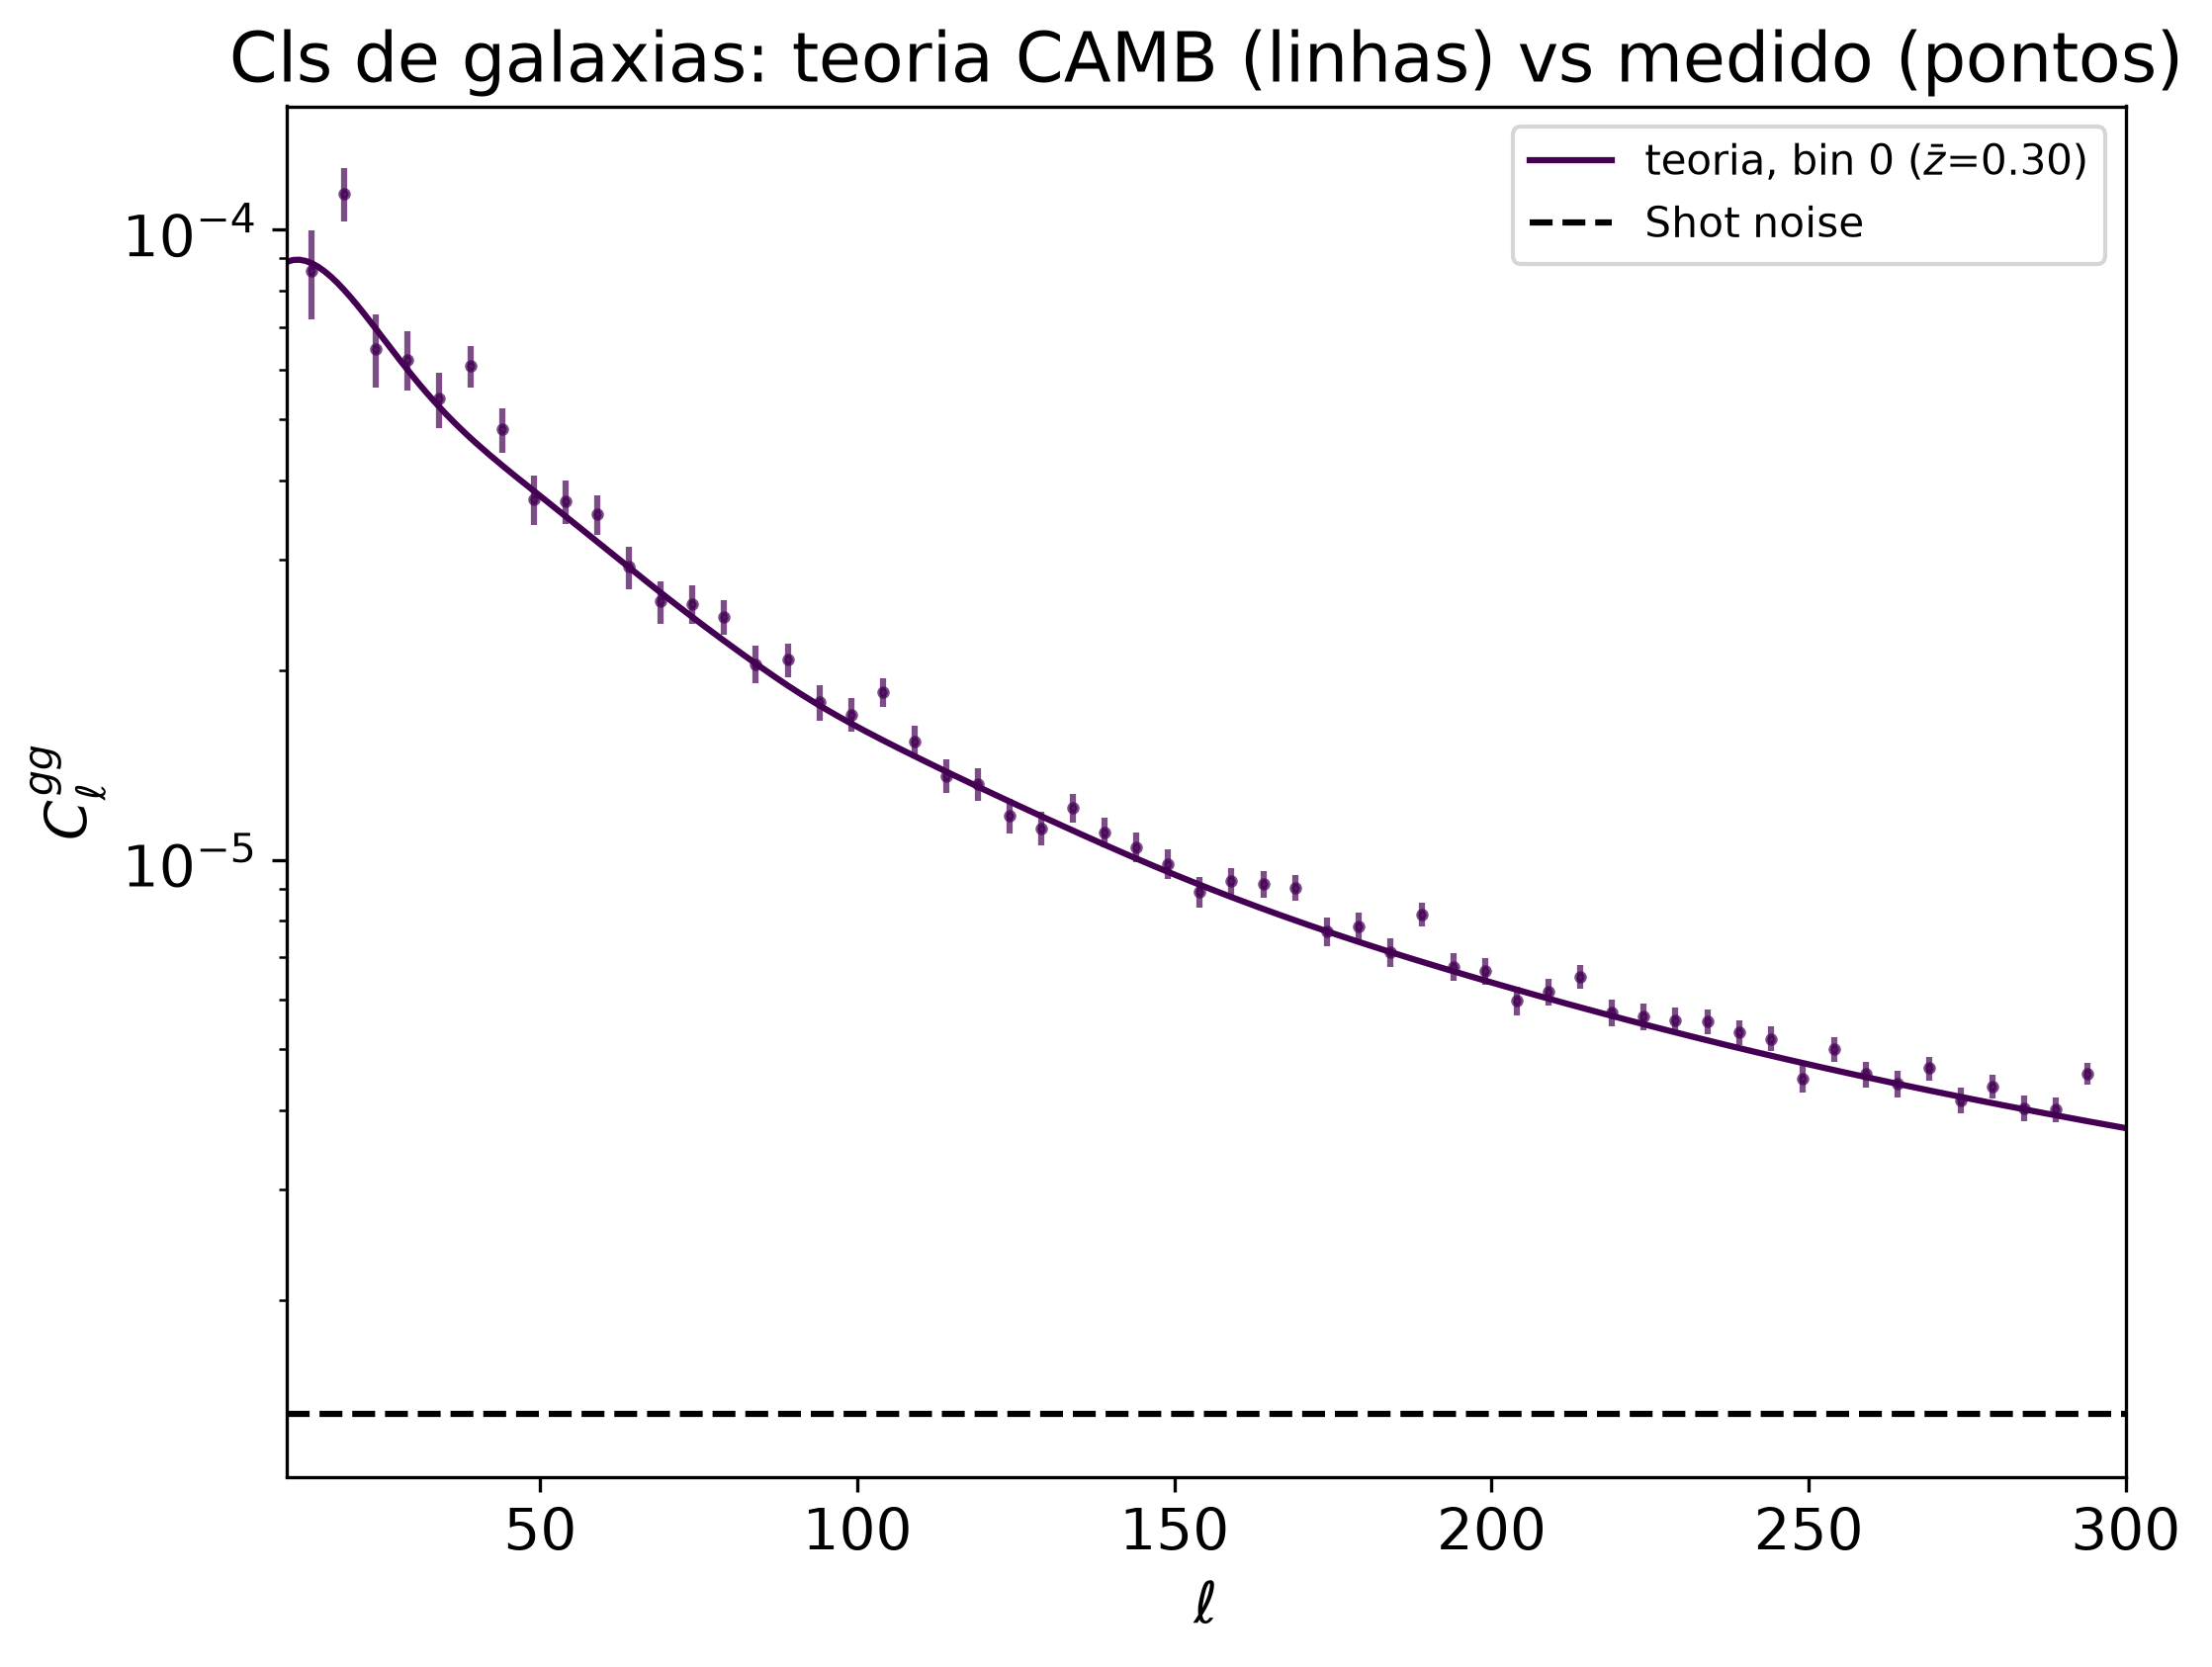

In [213]:
# Refazendo o plot dos Cls dados x teoria, agora com barras de erro

# Plot: auto-Cls por bin (+ medidos)
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)
colors = plt.cm.viridis(np.linspace(0, 0.9, Nbins))


ax.plot(ells_th[lmin:], cls_gg_theory[lmin:, 0, 0], color=colors[0],
            label=fr'teoria, bin 0 ($\bar z$={zbar[0]:.2f})')
    
ax.errorbar(x=b.get_effective_ells()[int(lmin/bs):], y=cls_gg[:, 0, 0][int(lmin/bs):], yerr=sigma_auto[int(lmin/bs):,0], fmt='.', ms=4,
                color=colors[0], alpha=0.7)

ax.axhline(N_gg[0], color='k', ls='--', label='Shot noise')

ax.set_xlim(lmin, lmax)
ax.set_xlabel(r'$\ell$')
ax.set_ylabel(r'$C_\ell^{gg}$')
plt.yscale('log')
ax.set_title('Cls de galaxias: teoria CAMB (linhas)'
             + (' vs medido (pontos)' ))
ax.legend(fontsize=10)
plt.show()

## Exercício: construir a likelihood dos Cls

- Vamos desprezar as correlações entre bins de redshift 
- Lembre que diferentes multipolos são descorrelacionados
- Vamos jogar fora grandes escalas (ell<10)
- Defina funções úteis: Cl teórico (função de Omega_m), Cl dos dados, Covariancia, Log-likelihood

Objetivo: Plotar o log da likelihood como função de Omega_m.
Segundo objetivo: estimar o Omega_m que maximiza a likelihood e o sua barra de erro (1sigma).